In [1]:
import pandas as pd
import json

# File path to your JSON data
file_path = "../Hyperparameters_search/save_it_here/intermediate_results3.jsonl"  # Update with the actual file path

# Read the JSON file line by line and store each JSON object in a list
data_list = []
with open(file_path, "r") as file:
    for line in file:
        data_list.append(json.loads(line.strip()))

# Normalize JSON data to a Pandas DataFrame
df = pd.json_normalize(data_list, sep='_')

# Display the DataFrame
#import ace_tools as tools
#tools.display_dataframe_to_user(name="Hyperparameter Search Results", dataframe=df)

import numpy as np

# Deal with runs that haven't converged
df.loc[df["metrics_observed_rmse"] == 0, df.columns[df.columns.str.startswith("metrics_")]] = np.nan
df['Converged'] = (df.metrics_observed_rmse==df.metrics_observed_rmse)

metrics_mask = [('metrics' in elt) for elt in df.columns]
metrics = df.columns[metrics_mask]

df = df[df.training_time > 50]

df

,training_time,hyperparameters_run_nb,hyperparameters_alpha,hyperparameters_beta,hyperparameters_noise_sigma,hyperparameters_noise_std,hyperparameters_use_mean_z,hyperparameters_detach_flag,hyperparameters_lr,hyperparameters_p_dataset,...,metrics_observed_uncertainty_error_corr,metrics_missing_rmse,metrics_missing_nll,metrics_missing_elbo,metrics_missing_coverage,metrics_missing_uncertainty_error_corr,metrics_latent_latent_ks,metrics_latent_latent_log_prob,metrics_reconstruction_overall_coverage,Converged
0,171.329547,1,1.0,1.000,0.001,0.05,True,True,0.001,0.1,...,-0.085944,0.559579,2698.661360,-87737.161360,0.348453,0.015551,NaN,-1.477538,0.688995,True
1,267.007767,1,1.0,1.000,0.001,0.05,True,True,0.001,0.3,...,-0.005126,0.757814,19693.967561,-84734.897249,0.579651,0.165000,NaN,-1.585286,0.715132,True
2,261.159417,1,1.0,1.000,0.001,0.05,True,True,0.001,0.5,...,-0.125828,0.710127,28861.041689,-74019.221377,0.535902,0.107368,NaN,-4.282284,0.660635,True
3,272.258635,1,1.0,1.000,0.001,0.05,True,True,0.001,0.7,...,0.105742,0.887720,86508.750325,-128387.941731,0.829108,0.194212,NaN,-5.343020,0.837831,True
4,161.660447,1,1.0,1.000,0.001,0.10,True,True,0.001,0.1,...,-0.154308,0.549290,2504.427577,-113727.888515,0.311160,0.105654,NaN,-1.454600,0.660952,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1169,89.273682,2,1.0,0.001,0.001,0.50,True,True,0.001,0.3,...,-0.318381,0.630752,10851.935683,-75509.619277,0.402720,0.153988,NaN,-3.535661,0.641799,True
1170,114.040510,2,1.0,0.001,0.001,0.50,True,True,0.001,0.5,...,-0.196886,0.726357,27568.835474,-69383.937036,0.598822,0.083732,NaN,-3.174694,0.738201,True
1171,83.383010,2,1.0,0.001,0.001,0.50,True,True,0.001,0.7,...,-0.256985,0.842163,50386.242784,-98097.852159,0.545592,0.189499,NaN,-6.541947,0.629101,True
1172,73.902986,2,1.0,0.001,0.010,0.50,True,True,0.001,0.1,...,-0.046431,0.554362,3067.170775,-103042.967650,0.593500,0.109990,NaN,-2.158418,0.778413,True


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches  # For custom legend

def plot_scatter_with_shaded_hues(df, x, y, hue1, hue2, mask=None):
    """
    Creates a scatter plot where the color represents `hue1` and the intensity represents `hue2`.

    Parameters:
    - df: DataFrame containing the data
    - x: Column name for x-axis
    - y: Column name for y-axis
    - hue1: Column name for base color categories
    - hue2: Column name for intensity variations (shading)
    - mask: Optional mask to filter df before plotting

    Returns:
    - None (displays the plot)
    """

    # Apply mask if provided
    if mask is not None:
        df = df[mask].copy()

    # Extract unique values for hue mapping
    unique_hue1 = sorted(df[hue1].unique())  # Base colors
    unique_hue2 = sorted(df[hue2].unique())  # Shades

    # Generate base colors from a categorical palette
    base_palette = sns.color_palette("Set1", n_colors=len(unique_hue1))

    # Create a mapping of (hue1 -> base color)
    hue1_to_color = {val: base_palette[i] for i, val in enumerate(unique_hue1)}

    # Function to generate LIGHTER shades of the base color
    def get_shaded_color(hue1_val, hue2_val):
        base_color = np.array(hue1_to_color[hue1_val])  # Convert to NumPy array
        white = np.array([1.0, 1.0, 1.0])  # White color for blending
        intensity = np.linspace(0.3, 1.0, len(unique_hue2))  # Control lightness
        hue2_index = unique_hue2.index(hue2_val)  # Find the index of hue2 value
        alpha = intensity[hue2_index]  # Define lighter intensity factor
        shaded_color = alpha * base_color + (1 - alpha) * white  # Blend with white
        return tuple(shaded_color)  # Convert back to tuple for plotting

    # Compute the final color mapping for each data point
    df['color'] = df.apply(lambda row: get_shaded_color(row[hue1], row[hue2]), axis=1)

    # Plot using Matplotlib scatter
    plt.figure(figsize=(18, 6))
    
    plt.scatter(
        df[x], df[y],
        c=df['color'].tolist(),  # Assign exact colors
        s=70,  # Adjust marker size
        alpha=0.99  # Slight transparency
    )

    # Create custom legend
    legend_patches = []
    for hue1_val in unique_hue1:
        for hue2_val in unique_hue2:
            color = get_shaded_color(hue1_val, hue2_val)
            label = f"{hue1}={hue1_val}, {hue2}={hue2_val}"
            legend_patches.append(mpatches.Patch(color=color, label=label))

    plt.legend(handles=legend_patches, title="Color Mapping", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlabel(x.replace('_', ' ').title())  # Improve axis labels
    plt.ylabel(y.replace('_', ' ').title())
    plt.title(f"Scatter Plot of {x} vs {y} with Shaded {hue1} and {hue2}")
    plt.tight_layout()

    plt.show()


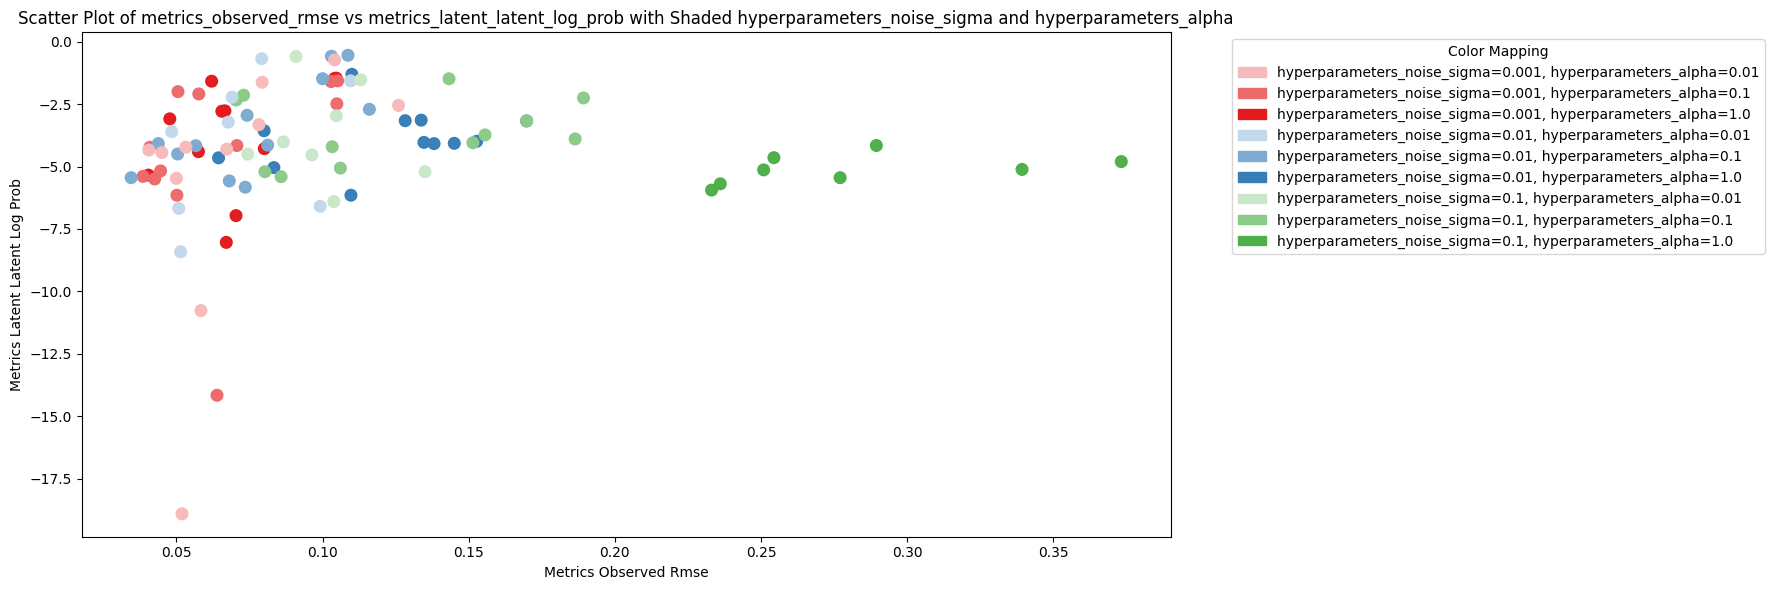

In [13]:
plot_scatter_with_shaded_hues(
    df=df, 
    x='metrics_observed_rmse', 
    y='metrics_latent_latent_log_prob', 
    hue1='hyperparameters_noise_sigma', 
    hue2='hyperparameters_alpha',
    mask=(df.hyperparameters_noise_std==0.05)
)

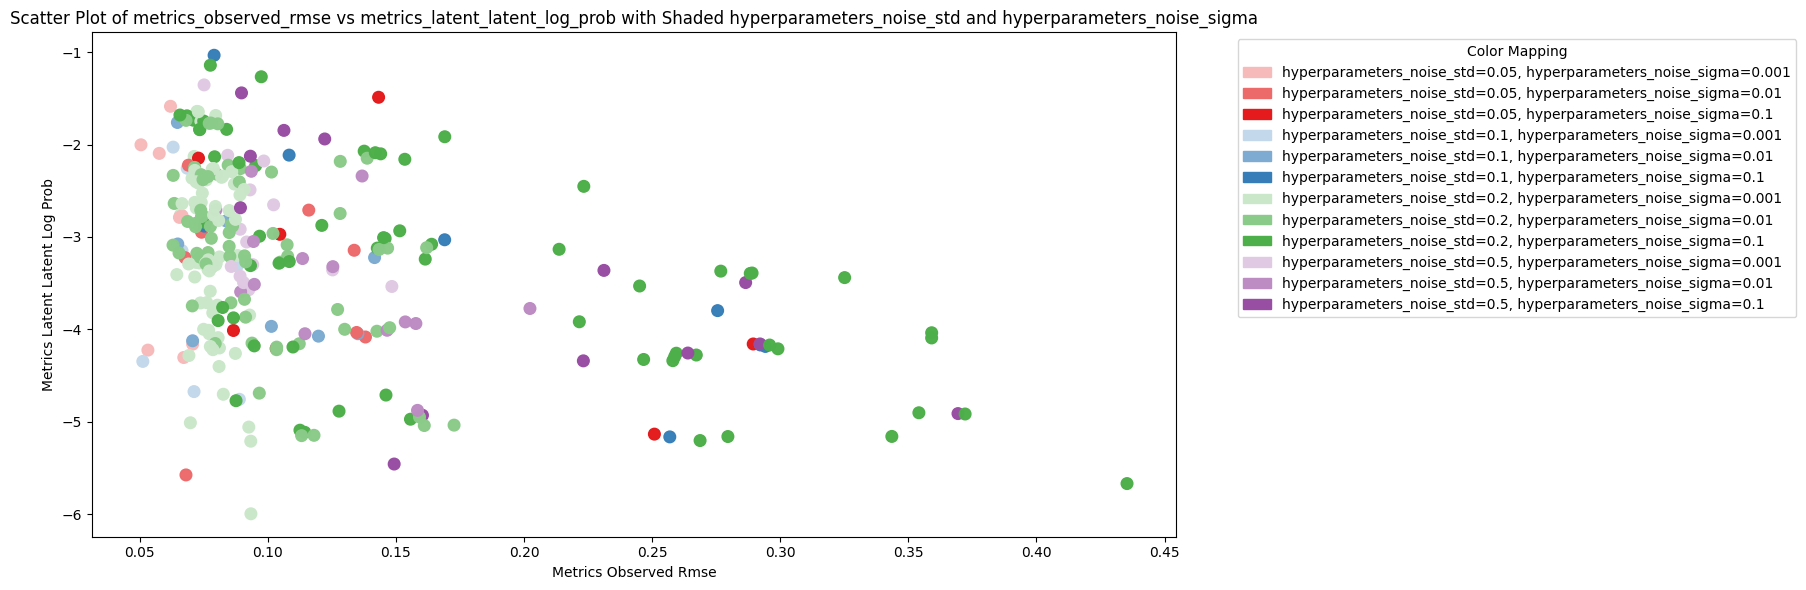

In [6]:
plot_scatter_with_shaded_hues(
    df=df, 
    x='metrics_observed_rmse', 
    y='metrics_latent_latent_log_prob', 
    hue1='hyperparameters_noise_std', 
    hue2='hyperparameters_noise_sigma',
    mask=(df.hyperparameters_p_dataset == 0.3)
)


<Axes: xlabel='hyperparameters_p_dataset', ylabel='metrics_missing_rmse'>

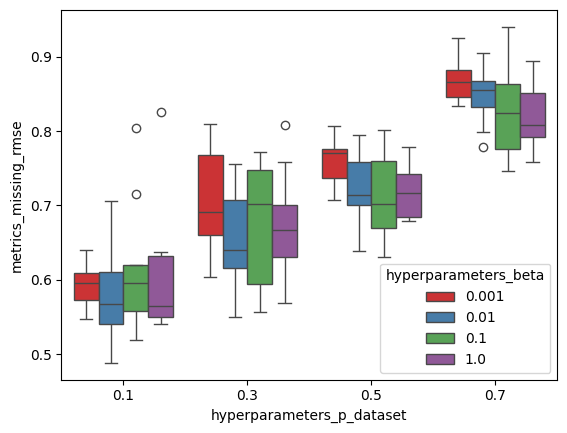

In [6]:
palette = sns.color_palette("Set1", n_colors=4)

sns.boxplot(df[(df.hyperparameters_alpha==1.)&(df.hyperparameters_noise_sigma==0.001)], 
x = 'hyperparameters_p_dataset',
y = 'metrics_missing_rmse',
hue = 'hyperparameters_beta',
palette = palette)

Text(0.5, 1.0, 'Alpha = 1')

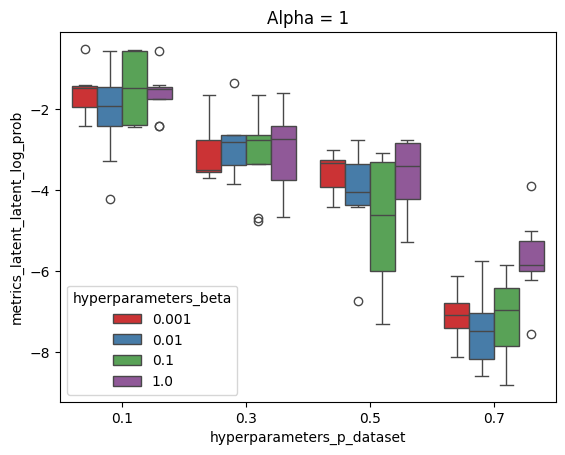

In [7]:
sns.boxplot(df[(df.hyperparameters_alpha==1.)&(df.hyperparameters_noise_sigma==0.001)], 
x = 'hyperparameters_p_dataset',
y = 'metrics_latent_latent_log_prob',
hue = 'hyperparameters_beta',
palette = palette)
plt.title('Alpha = 1')

Text(0.5, 1.0, 'Alpha = 1')

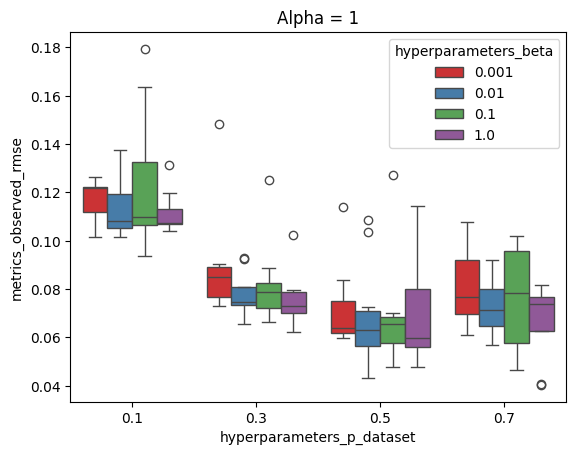

In [8]:
sns.boxplot(df[(df.hyperparameters_alpha==1.)&(df.hyperparameters_noise_sigma==0.001)], 
x = 'hyperparameters_p_dataset',
y = 'metrics_observed_rmse',
hue = 'hyperparameters_beta',
palette = palette)
plt.title('Alpha = 1')

/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_59028/766895085.py:1: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.boxplot(df[df.hyperparameters_alpha==1.],


<Axes: xlabel='hyperparameters_p_dataset', ylabel='metrics_missing_rmse'>

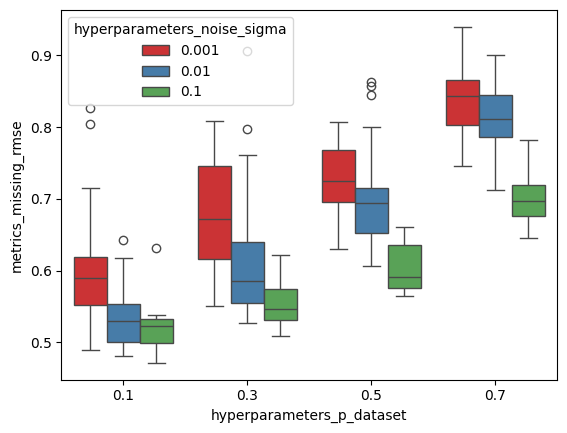

In [9]:
sns.boxplot(df[df.hyperparameters_alpha==1.], 
x = 'hyperparameters_p_dataset',
y = 'metrics_missing_rmse',
hue = 'hyperparameters_noise_sigma',
palette = palette)

In [206]:
df['metrics_overall_rmse'] = df.metrics_observed_rmse * (1 - df.hyperparameters_p_dataset) + df.metrics_missing_rmse * df.hyperparameters_p_dataset

/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_75110/1058440947.py:1: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.boxplot(df[df.hyperparameters_alpha==1.],


<Axes: xlabel='hyperparameters_p_dataset', ylabel='metrics_overall_rmse'>

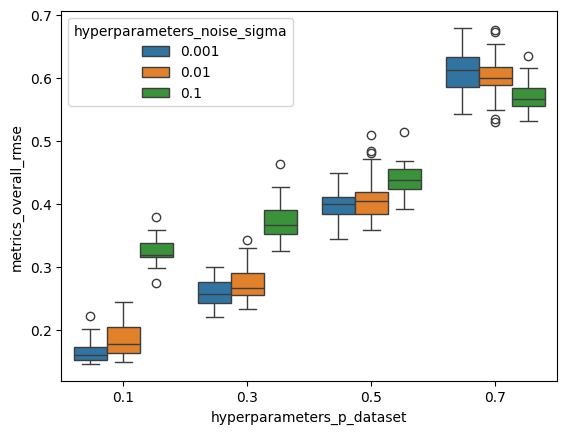

In [207]:
sns.boxplot(df[df.hyperparameters_alpha==1.], 
x = 'hyperparameters_p_dataset',
y = 'metrics_overall_rmse',
hue = 'hyperparameters_noise_sigma',
palette = palette)

/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_75110/79166372.py:1: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.boxplot(df[df.hyperparameters_alpha==1.],


<Axes: xlabel='hyperparameters_p_dataset', ylabel='metrics_observed_rmse'>

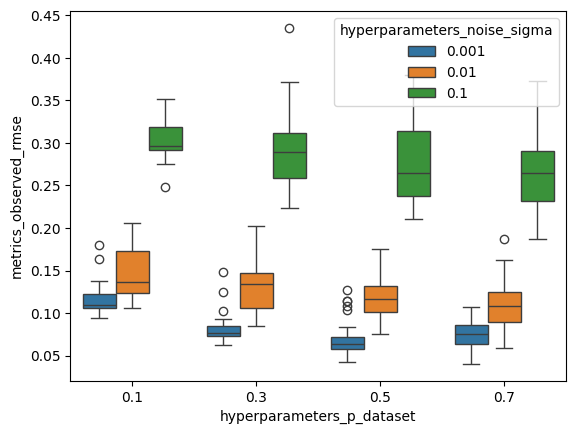

In [208]:
sns.boxplot(df[df.hyperparameters_alpha==1.], 
x = 'hyperparameters_p_dataset',
y = 'metrics_observed_rmse',
hue = 'hyperparameters_noise_sigma',
palette = palette)

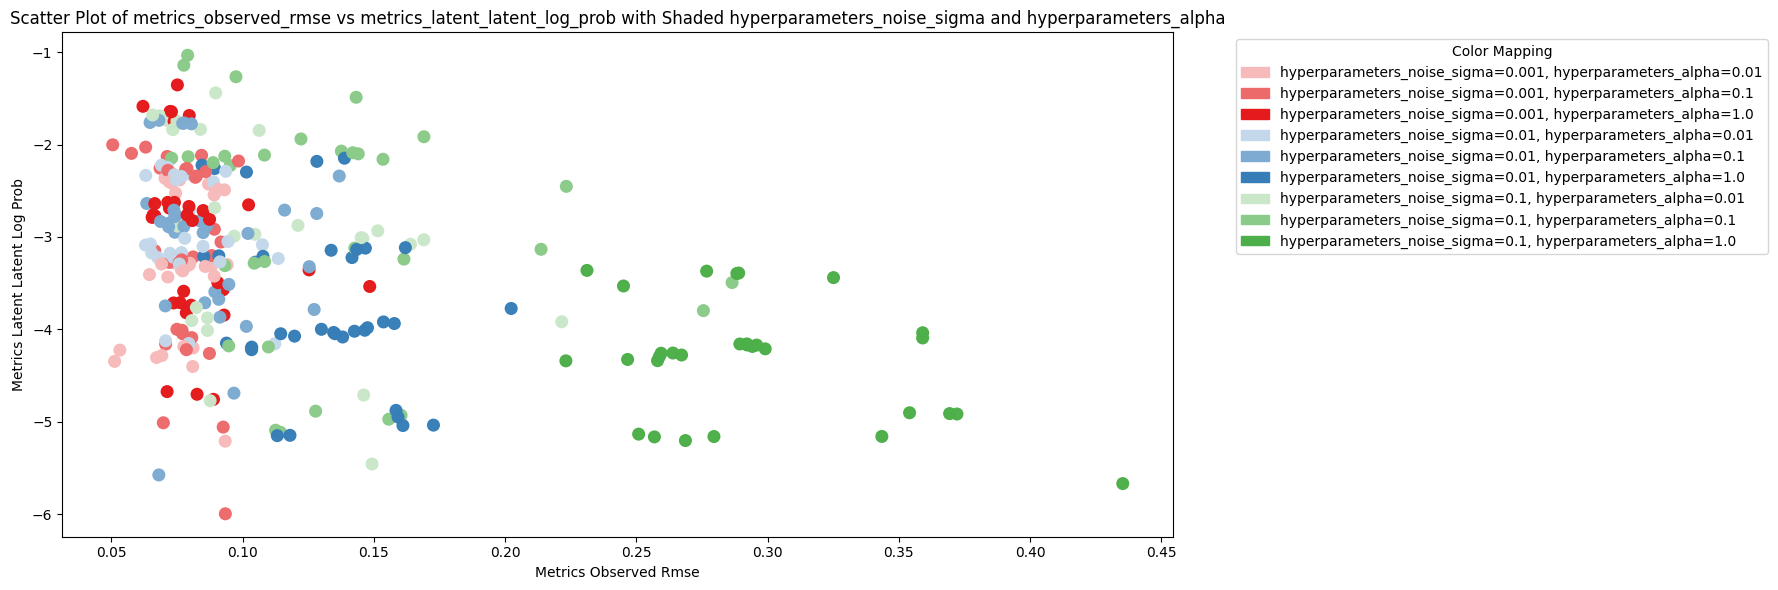

In [209]:
plot_scatter_with_shaded_hues(
    df=df, 
    x='metrics_observed_rmse', 
    y='metrics_latent_latent_log_prob', 
    hue1='hyperparameters_noise_sigma', 
    hue2='hyperparameters_alpha',
    mask=(df.hyperparameters_p_dataset == 0.3)
)


In [170]:
df_p03_good = df_p03[df_p03.good_results]
df_p03_bad = df_p03[~df_p03.good_results]

/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_75110/2238119828.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_p03['good_results'] = (df_p03.metrics_observed_rmse < .12) & (df_p03.metrics_latent_latent_log_prob > -2.3)


<Axes: xlabel='hyperparameters_noise_sigma', ylabel='hyperparameters_alpha'>

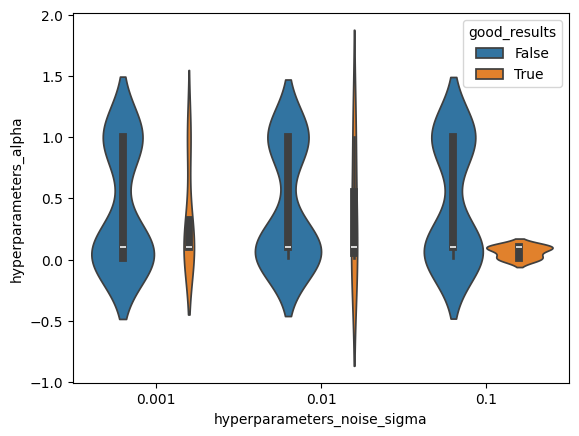

In [165]:
df_p03 = df[df.hyperparameters_p_dataset == 0.3]
df_p03['good_results'] = (df_p03.metrics_observed_rmse < .12) & (df_p03.metrics_latent_latent_log_prob > -2.3)

sns.violinplot(df_p03,
            x = 'hyperparameters_noise_sigma',
            y = 'hyperparameters_alpha',
            hue = 'good_results')

In [ ]:
mask = df.hyperparameters_p_dataset == 0.3
good_results = (df.metrics_observed_rmse > .12) & (df.metrics_latent_latent_log_prob > -2.3)

sns.scatterplot(df[mask])

In [ ]:
df

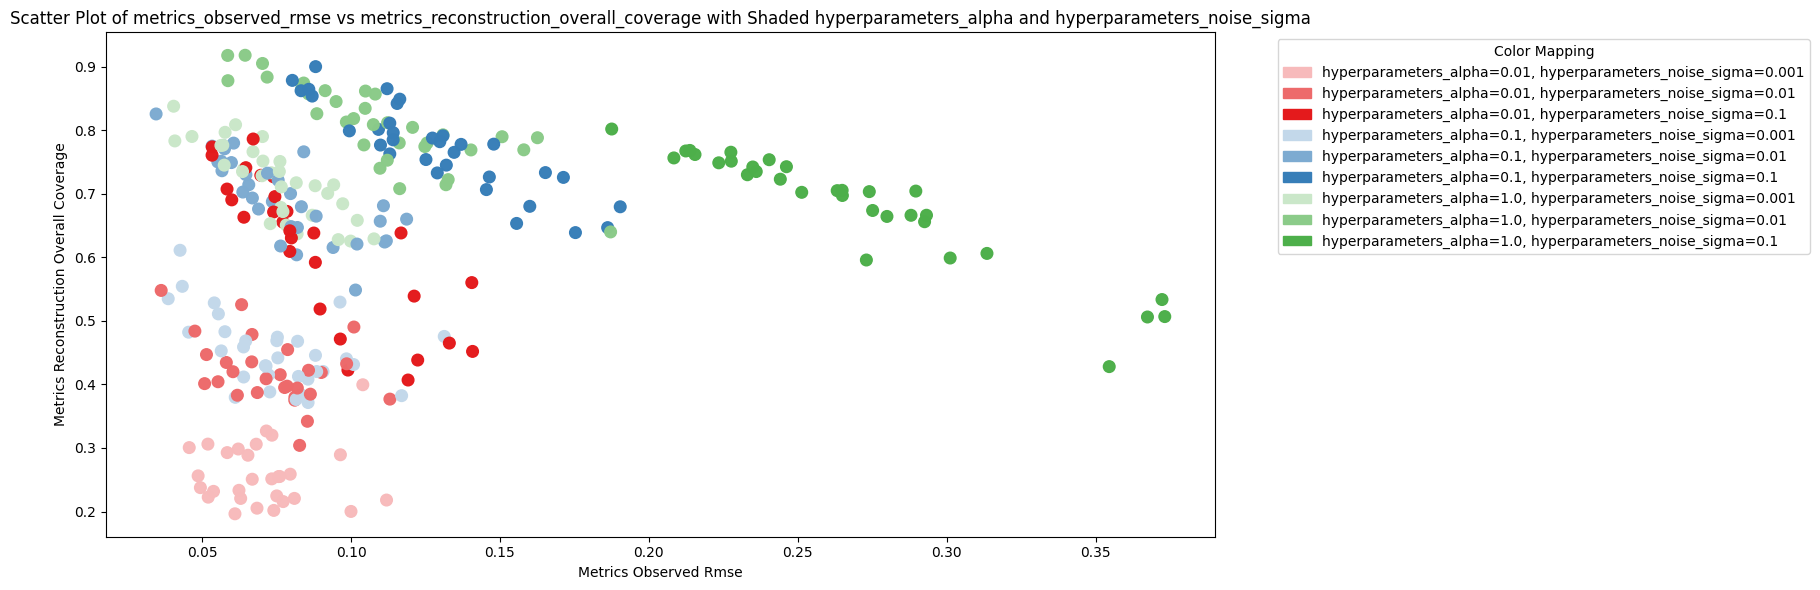

In [210]:
plot_scatter_with_shaded_hues(
    df=df, 
    x='metrics_observed_rmse', 
    y='metrics_reconstruction_overall_coverage', 
    hue2='hyperparameters_noise_sigma', 
    hue1='hyperparameters_alpha',
    mask=(df.hyperparameters_p_dataset == 0.7)
)


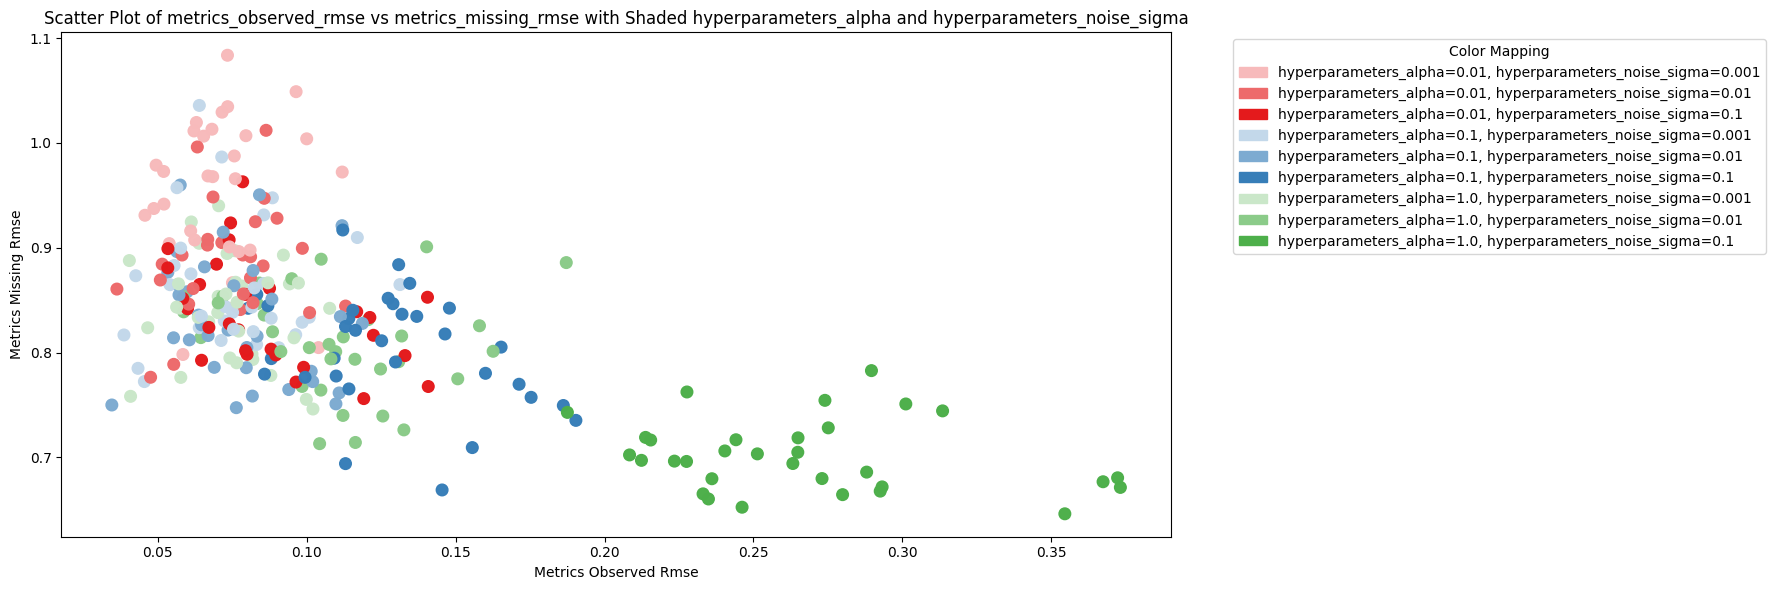

In [211]:
plot_scatter_with_shaded_hues(
    df=df, 
    x='metrics_observed_rmse', 
    y='metrics_missing_rmse', 
    hue2='hyperparameters_noise_sigma', 
    hue1='hyperparameters_alpha',
    mask=(df.hyperparameters_p_dataset == 0.7)
)


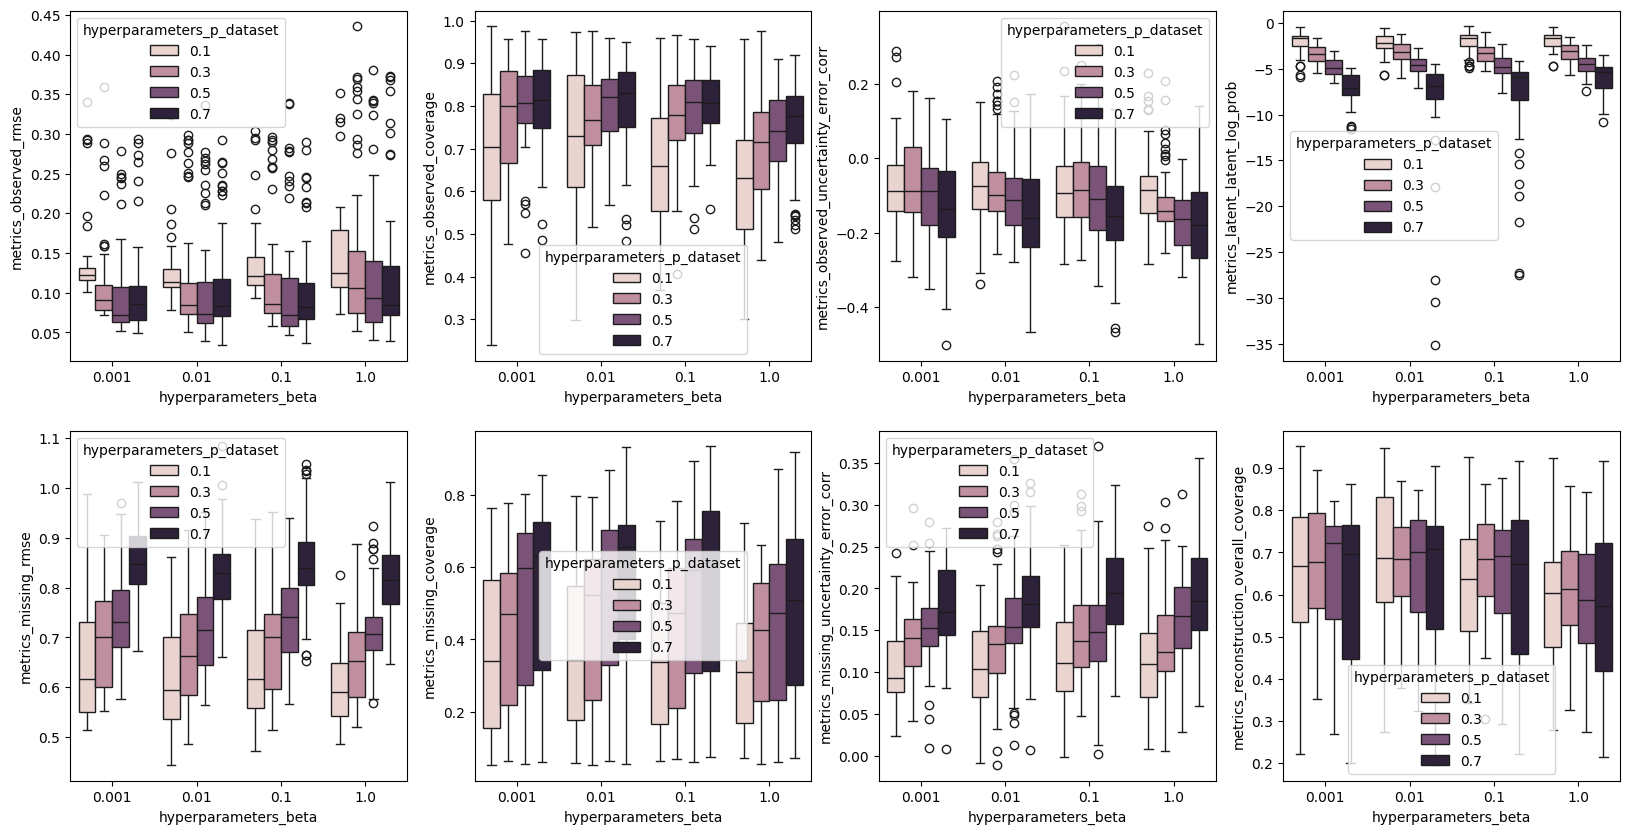

In [212]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics_use_mean_z = ['metrics_observed_rmse', 'metrics_observed_coverage', 
       'metrics_observed_uncertainty_error_corr','metrics_latent_latent_log_prob',
       'metrics_missing_rmse','metrics_missing_coverage', 
       'metrics_missing_uncertainty_error_corr','metrics_reconstruction_overall_coverage']
fig, ax = plt.subplots(2,4, figsize=(20,10))
for i,metric in enumerate(metrics_use_mean_z):
    sns.boxplot(df, y = metric,     
                hue = 'hyperparameters_p_dataset', 
                x = "hyperparameters_beta", 
                ax = ax[i//4, i%4]);
#ax[0, 0].set_yscale('log')
#ax[1, 0].set_yscale('log')

/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_75110/823673654.py:30: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  boxplot = sns.boxplot(
/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_75110/823673654.py:30: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  boxplot = sns.boxplot(
/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_75110/823673654.py:30: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  boxplot = sns.boxplot(
/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_75110/823673654.py:30: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  boxplot = sns.boxplot(
/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_75110/823673654.py:30: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  boxplot = sns.boxp

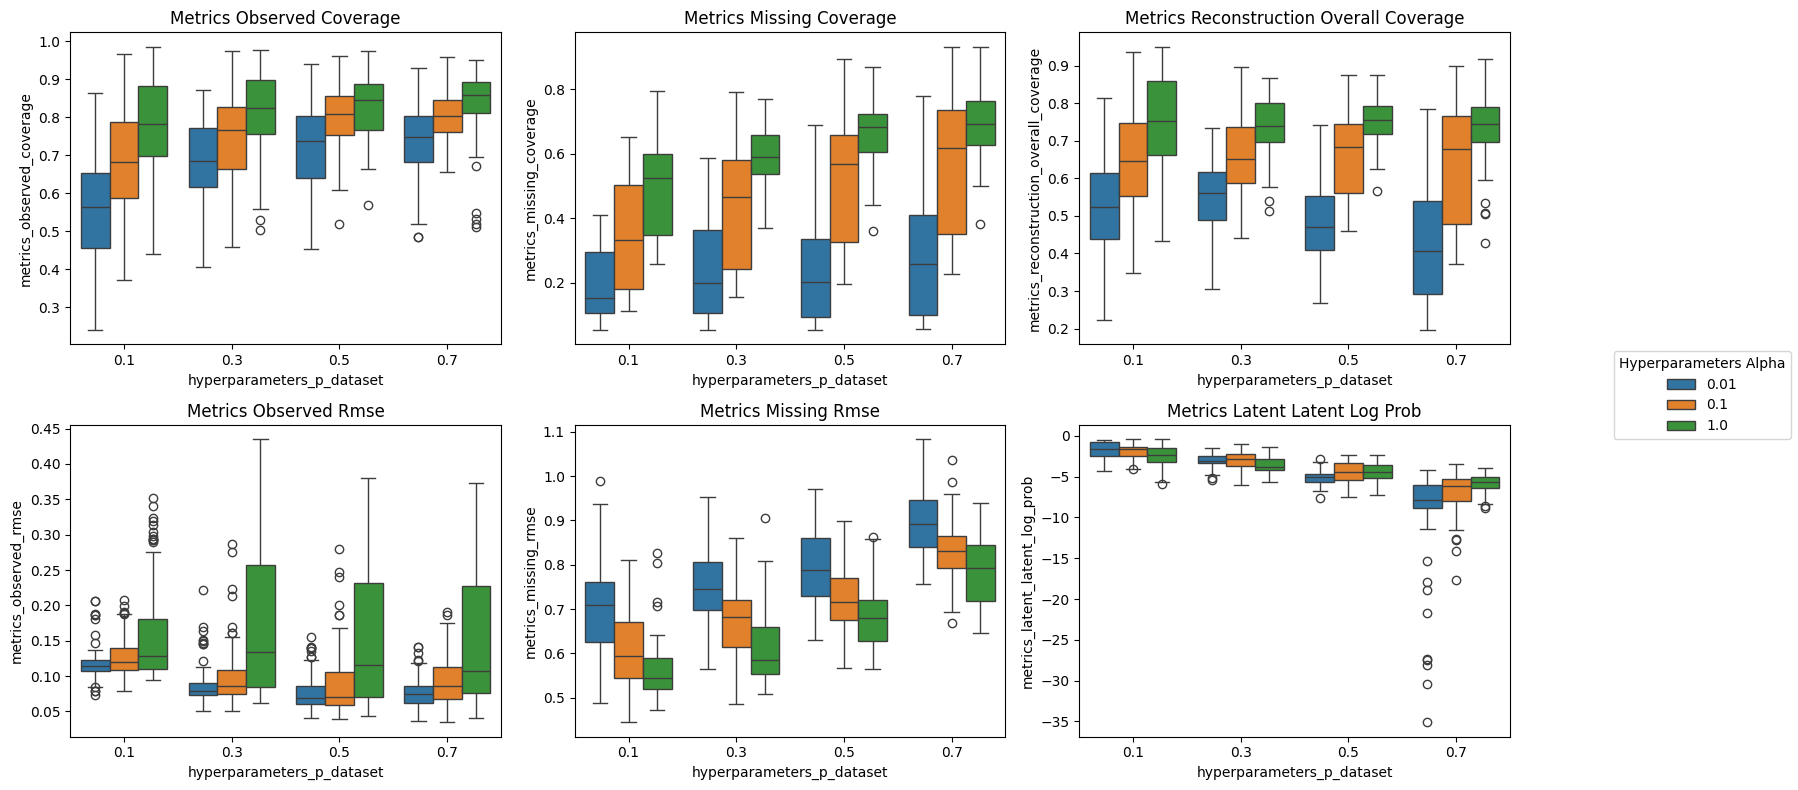

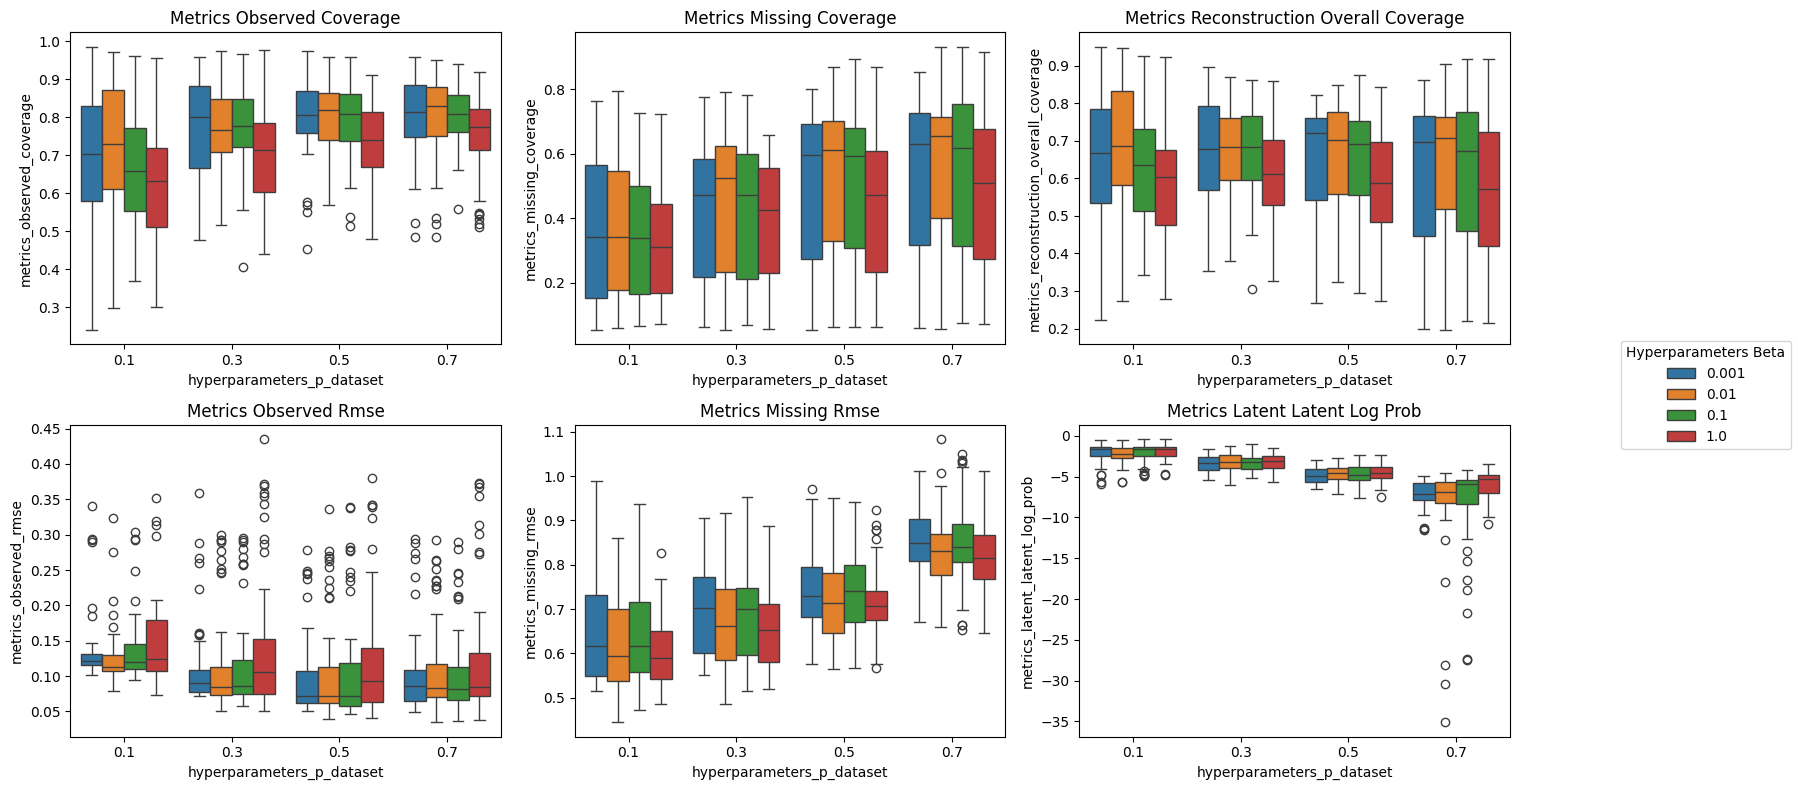

/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_75110/823673654.py:30: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  boxplot = sns.boxplot(
/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_75110/823673654.py:30: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  boxplot = sns.boxplot(
/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_75110/823673654.py:30: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  boxplot = sns.boxplot(
/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_75110/823673654.py:30: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  boxplot = sns.boxplot(
/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_75110/823673654.py:30: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  boxplot = sns.boxp

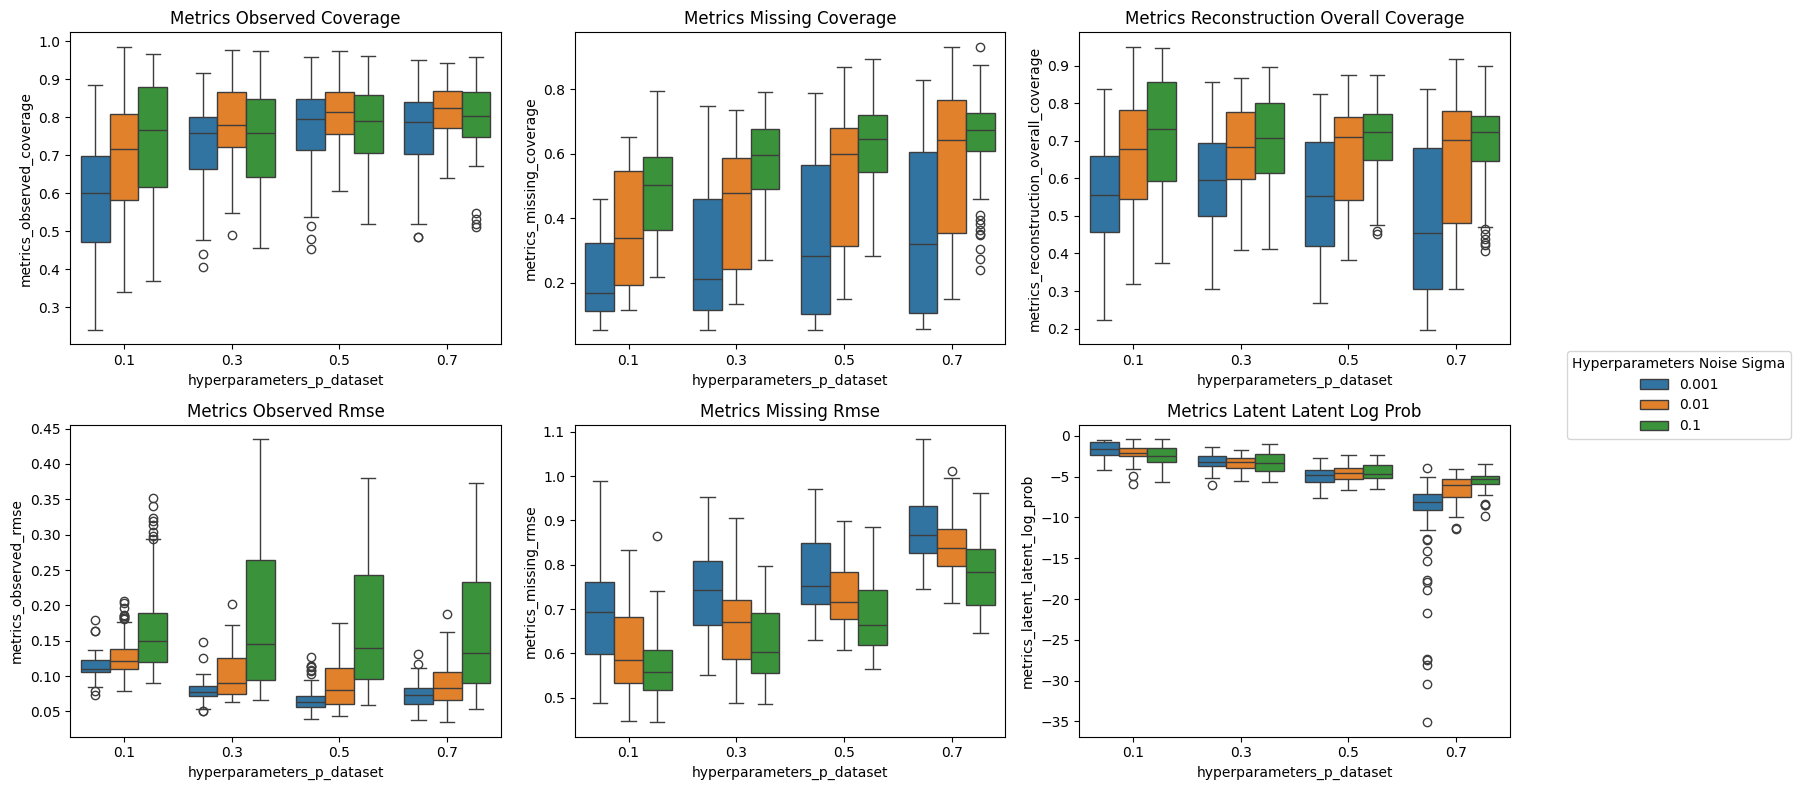

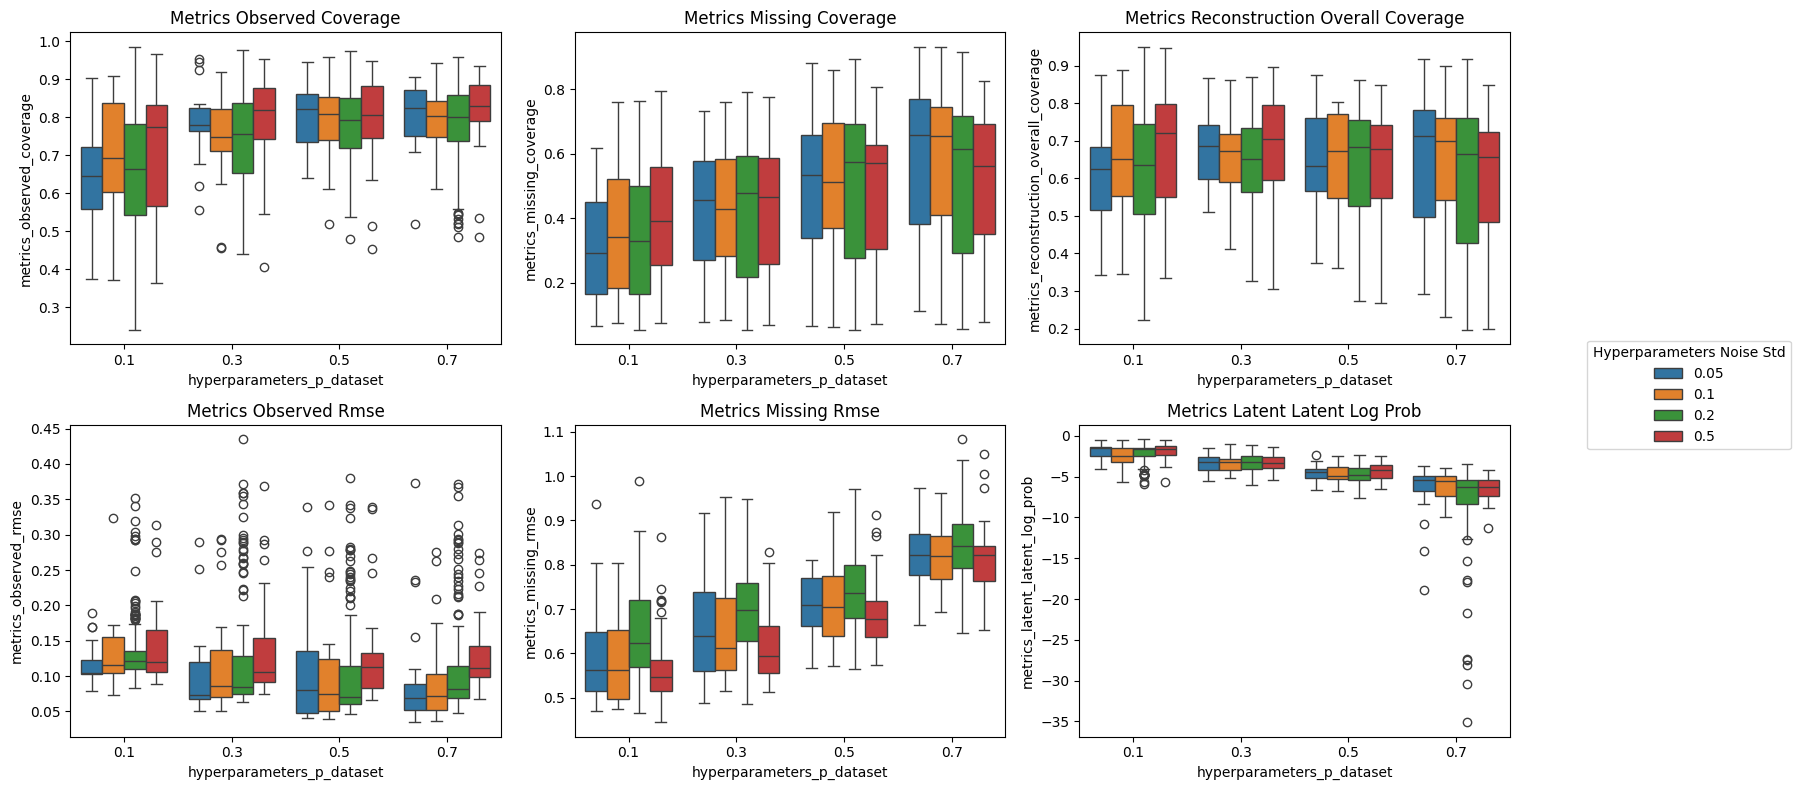

/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_75110/823673654.py:30: UserWarning: The palette list has more values (4) than needed (1), which may not be intended.
  boxplot = sns.boxplot(
/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_75110/823673654.py:30: UserWarning: The palette list has more values (4) than needed (1), which may not be intended.
  boxplot = sns.boxplot(
/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_75110/823673654.py:30: UserWarning: The palette list has more values (4) than needed (1), which may not be intended.
  boxplot = sns.boxplot(
/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_75110/823673654.py:30: UserWarning: The palette list has more values (4) than needed (1), which may not be intended.
  boxplot = sns.boxplot(
/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_75110/823673654.py:30: UserWarning: The palette list has more values (4) than needed (1), which may not be intended.
  boxplot = sns.boxp

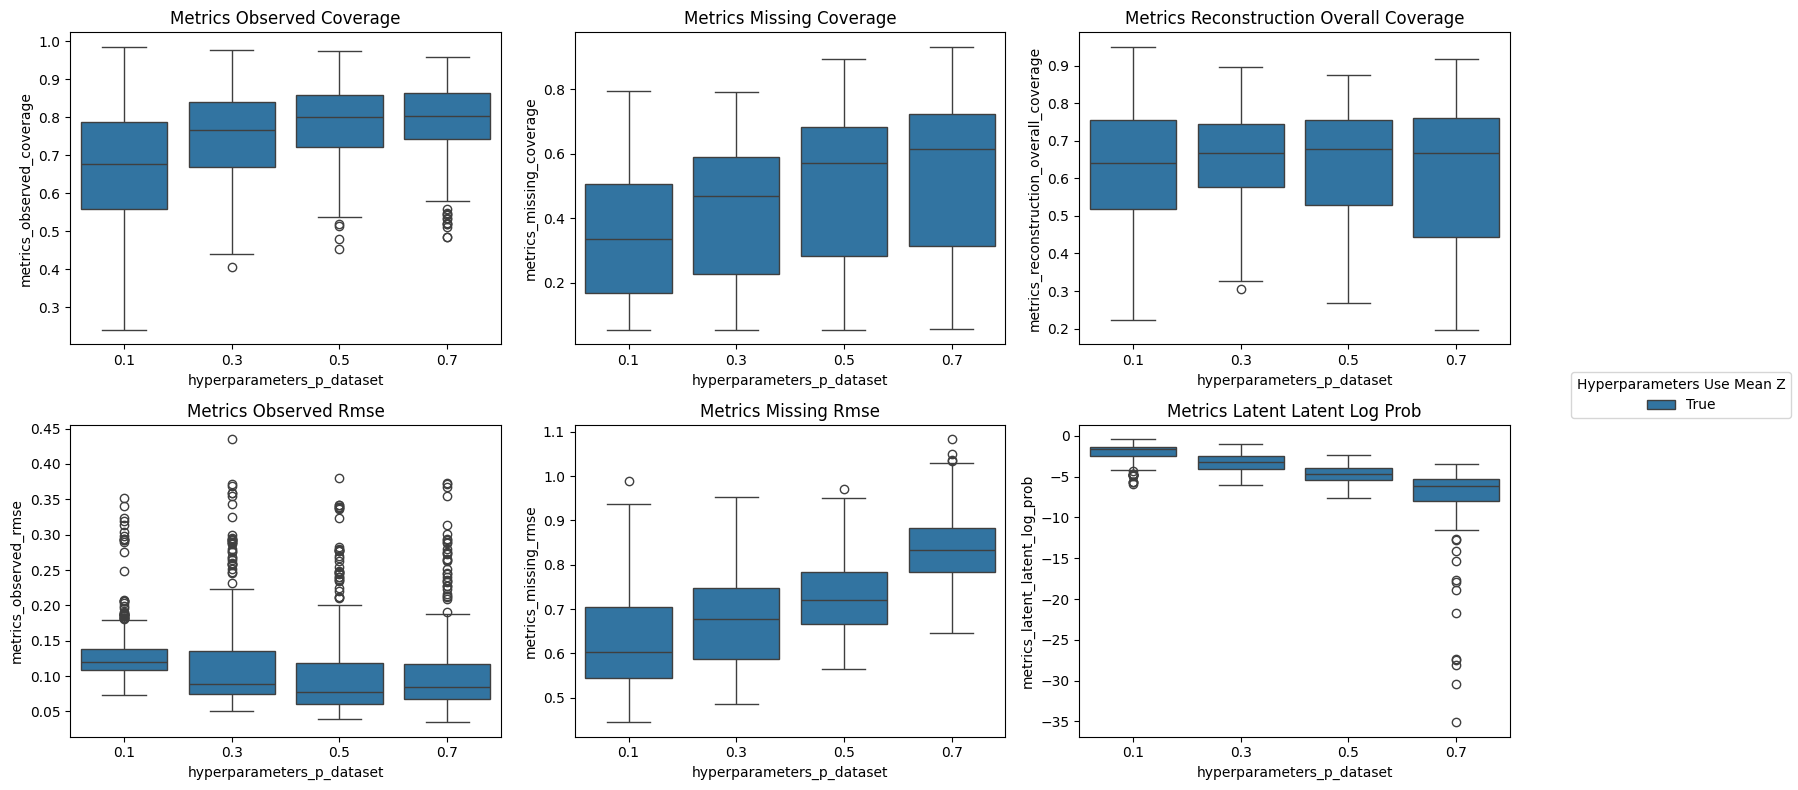

/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_75110/823673654.py:54: UserWarning: The palette list has more values (4) than needed (1), which may not be intended.
  sns.boxplot(


<Axes: title={'center': 'Metrics Latent Latent Log Prob'}, xlabel='hyperparameters_p_dataset', ylabel='metrics_latent_latent_log_prob'>

In [213]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the metrics in a logical order
metrics = [
    'metrics_observed_coverage', 
    'metrics_missing_coverage', 
    'metrics_reconstruction_overall_coverage',
    'metrics_observed_rmse', 
    'metrics_missing_rmse', 
    'metrics_latent_latent_log_prob'
]

# Extract hyperparameter columns
hyperparams = df.keys()[2:7].values

# Use a Seaborn color palette (can also try 'deep', 'pastel', 'muted', 'Set2', etc.)
palette = sns.color_palette('tab10', n_colors=4)

# Iterate over each hyperparameter and generate plots
for hyperparam in hyperparams:
           
       fig, axes = plt.subplots(2, 3, figsize=(18, 8))
       handles, labels = None, None

       axes = axes.flatten()  # Flatten for easy indexing
       
       for i, metric in enumerate(metrics):
              
              boxplot = sns.boxplot(
              data=df, 
              x='hyperparameters_p_dataset', 
              y=metric, 
              hue=hyperparam, 
              ax=axes[i],
              palette=palette
              )

              if handles is None or labels is None:
                     handles, labels = boxplot.get_legend_handles_labels()
              axes[i].legend_.remove();  # Remove individual legends

              axes[i].set_title(metric.replace('_', ' ').title());  # Improve titles

       # Add a single legend on the side
       fig.legend(handles, labels, loc='center right', title=hyperparam.replace('_', ' ').title());
       plt.tight_layout(rect=[0, 0, 0.85, 1]);  # Adjust layout to fit legend
       plt.show();
       #axes[i].legend(title=hyperparam, loc='best')  # Better legend placement

    #plt.tight_layout()  # Adjust layout for better spacing
    #plt.show()

sns.boxplot(
       data=df, 
       x='hyperparameters_p_dataset', 
       y=metric, 
       hue=hyperparam, 
       ax=axes[i],
       palette=palette
       )


<Axes: >

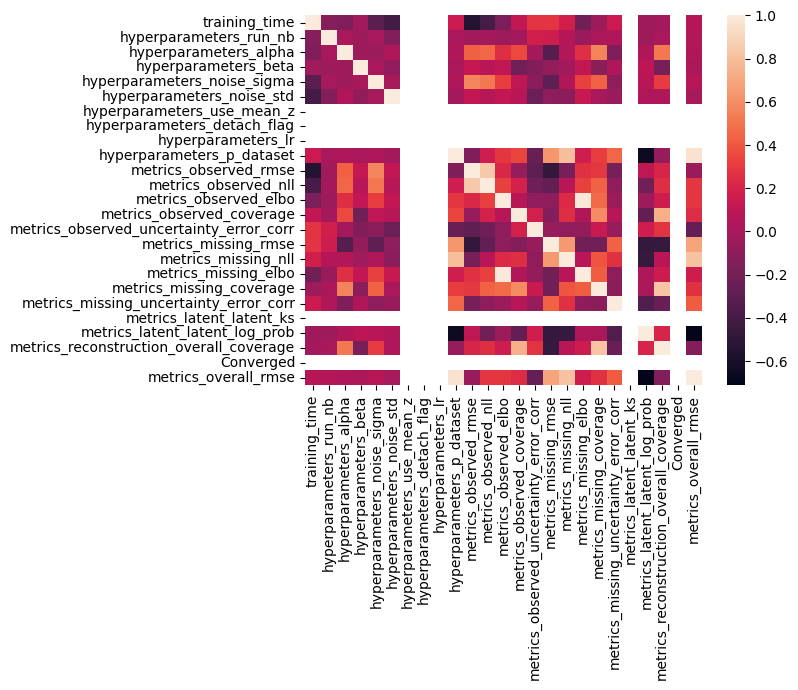

In [214]:
sns.heatmap(df.corr())

<Axes: xlabel='hyperparameters_p_dataset', ylabel='metrics_missing_coverage'>

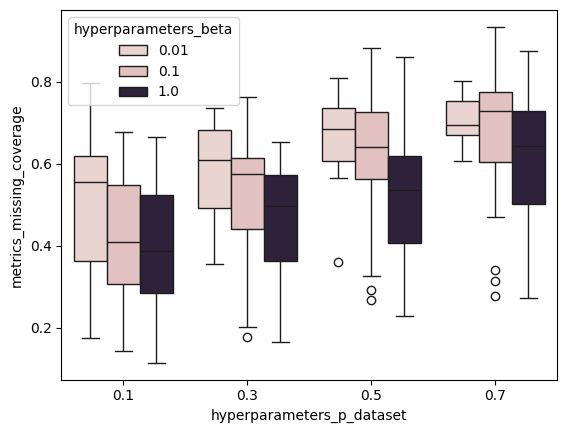

In [15]:
import seaborn as sns

sns.boxplot(df,
            x = 'hyperparameters_p_dataset',
            y = 'metrics_missing_coverage',
            hue = 'hyperparameters_beta')

<Axes: xlabel='metrics_missing_coverage', ylabel='metrics_missing_rmse'>

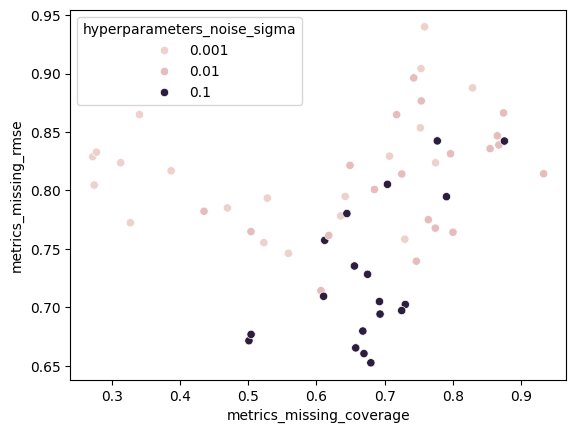

In [16]:
p = 0.7

sns.scatterplot(df[df.hyperparameters_p_dataset==p],
                x = 'metrics_missing_coverage',
                y = 'metrics_missing_rmse',
                hue = 'hyperparameters_noise_sigma'
                )